In [ ]:
import numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix as cm
import torch
import torch.nn as nn
import torch.optim as opt
import torchvision
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

In [ ]:
train_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])#, transforms.RandomHorizontalFlip(), transforms.RandomRotation(10), transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)])

In [ ]:
test_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])#, transforms.RandomHorizontalFlip(), transforms.RandomRotation(10) , transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)])

In [ ]:
dataset = torchvision.datasets.CIFAR10(root = r'/Users/Sohaib\'s Macbook Air/Documents/NUST 22-26/Internship - EBRYX/ML - VS Code/Week 06', train = True, download = True, transform = train_transform)

100%|██████████| 170M/170M [00:04<00:00, 41.0MB/s]


In [ ]:
test_dataset = torchvision.datasets.CIFAR10(root = r'/Users/Sohaib\'s Macbook Air/Documents/NUST 22-26/Internship - EBRYX/ML - VS Code/Week 06', train = False, download = True, transform = train_transform)

In [ ]:
train_load = DataLoader(dataset, batch_size = 64, shuffle = True, num_workers = 2)

In [ ]:
test_load = DataLoader(test_dataset, batch_size = 64, shuffle = False, num_workers = 2)

In [ ]:
image, label = dataset[0]
image

tensor([[[-0.5373, -0.6627, -0.6078,  ...,  0.2392,  0.1922,  0.1608],
         [-0.8745, -1.0000, -0.8588,  ..., -0.0353, -0.0667, -0.0431],
         [-0.8039, -0.8745, -0.6157,  ..., -0.0745, -0.0588, -0.1451],
         ...,
         [ 0.6314,  0.5765,  0.5529,  ...,  0.2549, -0.5608, -0.5843],
         [ 0.4118,  0.3569,  0.4588,  ...,  0.4431, -0.2392, -0.3490],
         [ 0.3882,  0.3176,  0.4039,  ...,  0.6941,  0.1843, -0.0353]],

        [[-0.5137, -0.6392, -0.6235,  ...,  0.0353, -0.0196, -0.0275],
         [-0.8431, -1.0000, -0.9373,  ..., -0.3098, -0.3490, -0.3176],
         [-0.8118, -0.9451, -0.7882,  ..., -0.3412, -0.3412, -0.4275],
         ...,
         [ 0.3333,  0.2000,  0.2627,  ...,  0.0431, -0.7569, -0.7333],
         [ 0.0902, -0.0353,  0.1294,  ...,  0.1608, -0.5137, -0.5843],
         [ 0.1294,  0.0118,  0.1137,  ...,  0.4431, -0.0745, -0.2784]],

        [[-0.5059, -0.6471, -0.6627,  ..., -0.1529, -0.2000, -0.1922],
         [-0.8431, -1.0000, -1.0000,  ..., -0

In [ ]:
print('the size of image is [channels, pixels, pixels]: ', image.size())

the size of image is [channels, pixels, pixels]:  torch.Size([3, 32, 32])


In [ ]:
classes = ['plane', 'bird', 'deer', 'car', 'cat', 'dog', 'truck', 'ship', 'horse', 'frog']
for i in range(len(classes)):
    print(classes[i])

plane
bird
deer
car
cat
dog
truck
ship
horse
frog


In [ ]:
'''class Conv_NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(3, 10, 5, padding = 0, stride = 1) # ((32 - 5) + stride)/stride -> [12, 28, 28]
    self.pool = nn.MaxPool2d(2, 2) # 28/2(max pool size) -> [12, 14, 14]
    self.conv2 = nn.Conv2d(10, 20, 5, padding = 0, stride = 1) # same calc -> [20, 10, 10]
    # flatten the layer -> 20 * 5 * 5
    self.layer1 = nn.Linear(20 * 5 * 5, 100)
    self.layer2 = nn.Linear(100, 84)
    self.layer3 = nn.Linear(84, 10)
    self.relu = nn.ReLU()
    self.dropout1 = nn.Dropout2d(0.3)

  def forward(self, x):
    output1 = self.conv1(x)
    output2 = self.relu(output1)
    output3 = self.pool(output2)
    output4 = self.conv2(output3)
    output5 = self.relu(output4)
    output6 = self.pool(output5)
    output7 = torch.flatten(output6, 1)
    output8 = self.layer1(output7)
    output9 = self.relu(output8)
    output10 = self.layer2(output9)
    output11 = self.relu(output10)
    output12 = self.layer3(output11)
    return output12

model = Conv_NeuralNetwork()'''

'''class Conv_NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1, stride=1) # Input: [3, 32, 32] -> Output: [64, 32, 32] (padding = 1 maintains size)
        self.bn1 = nn.BatchNorm2d(64)

        self.conv2 = nn.Conv2d(64, 64, 3, padding=1, stride=1) # Input: [64, 32, 32] -> Output: [64, 32, 32] (padding = 1 maintains size)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2) # Input: [64, 32, 32] -> Output: [64, 16, 16] (calculation: 32/2 = 16)
        self.dropout1 = nn.Dropout2d(0.25)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1, stride=1) # Input: [64, 16, 16] -> Output: [128, 16, 16] (padding = 1 maintains size)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 128, 3, padding=1, stride=1) # Input: [128, 16, 16] -> Output: [128, 16, 16] (padding = 1 maintains size)
        self.bn4 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2) # Input: [128, 16, 16] -> Output: [128, 8, 8] (calculation: 16/2 = 8)
        self.dropout2 = nn.Dropout2d(0.25)

        self.conv5 = nn.Conv2d(128, 256, 3, padding=1, stride=1) # Input: [128, 8, 8] -> Output: [256, 8, 8] (padding=1 maintains size)
        self.bn5 = nn.BatchNorm2d(256)

        self.conv6 = nn.Conv2d(256, 256, 3, padding=1, stride=1) # Input: [256, 8, 8] -> Output: [256, 8, 8] (padding=1 maintains size)
        self.bn6 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(2, 2) # Input: [256, 8, 8] -> Output: [256, 4, 4] (calculation: 8/2 = 4)
        self.dropout3 = nn.Dropout2d(0.25)

        self.layer1 = nn.Linear(256 * 4 * 4, 1024) # Input: 256 * 4 * 4 = 4096 features -> Output: 1024 features
        self.bn7 = nn.BatchNorm1d(1024)
        self.dropout4 = nn.Dropout(0.5)
        self.layer2 = nn.Linear(1024, 512) # Input: 1024 features -> Output: 512 features
        self.bn8 = nn.BatchNorm1d(512)
        self.dropout5 = nn.Dropout(0.5)
        self.layer3 = nn.Linear(512, 10) # Input: 512 features -> Output: 10 features (one per class)
        self.relu = nn.ReLU()

    def forward(self, x):
        output1 = self.conv1(x)
        output2 = self.bn1(output1)
        output3 = self.relu(output2)
        output4 = self.conv2(output3)
        output5 = self.bn2(output4)
        output6 = self.relu(output5)
        output7 = self.pool1(output6)
        output8 = self.dropout1(output7)
        output9 = self.conv3(output8)
        output10 = self.bn3(output9)
        output11 = self.relu(output10)
        output12 = self.conv4(output11)
        output13 = self.bn4(output12)
        output14 = self.relu(output13)
        output15 = self.pool2(output14)
        output16 = self.dropout2(output15)
        output17 = self.conv5(output16)
        output18 = self.bn5(output17)
        output19 = self.relu(output18)
        output20 = self.conv6(output19)
        output21 = self.bn6(output20)
        output22 = self.relu(output21)
        output23 = self.pool3(output22)
        output24 = self.dropout3(output23)
        output25 = torch.flatten(output24, 1)
        output26 = self.layer1(output25)
        output27 = self.bn7(output26)
        output28 = self.relu(output27)
        output29 = self.dropout4(output28)
        output30 = self.layer2(output29)
        output31 = self.bn8(output30)
        output32 = self.relu(output31)
        output33 = self.dropout5(output32)
        output34 = self.layer3(output33)

        return output34

model = Conv_NeuralNetwork()'''

class Conv_NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1, bias=False)  # Input: [3, 32, 32] -> Output: [16, 32, 32] (padding=1 maintains size)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 16, 3, padding=1, bias=False)  # Input: [16, 32, 32] -> Output: [16, 32, 32] (padding=1 maintains size)
        self.bn2 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(2, 2)  # Input: [16, 32, 32] -> Output: [16, 16, 16] (calculation: 32/2 = 16)
        self.dropout1 = nn.Dropout2d(0.25)
        self.depthwise1 = nn.Conv2d(16, 16, 3, padding=1, groups=16, bias=False)  # Depthwise: Input: [16, 16, 16] -> Output: [16, 16, 16]
        self.pointwise1 = nn.Conv2d(16, 32, 1, bias=False)  # Pointwise: Input: [16, 16, 16] -> Output: [32, 16, 16]
        self.bn3 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 32, 3, padding=1, bias=False)  # Input: [32, 16, 16] -> Output: [32, 16, 16]
        self.bn4 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2, 2)  # Input: [32, 16, 16] -> Output: [32, 8, 8] (calculation: 16/2 = 8)
        self.dropout2 = nn.Dropout2d(0.25)
        self.depthwise2 = nn.Conv2d(32, 32, 3, padding=1, groups=32, bias=False)  # Depthwise: Input: [32, 8, 8] -> Output: [32, 8, 8]
        self.pointwise2 = nn.Conv2d(32, 64, 1, bias=False)  # Pointwise: Input: [32, 8, 8] -> Output: [64, 8, 8]
        self.bn5 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, 3, padding=1, bias=False)  # Input: [64, 8, 8] -> Output: [64, 8, 8]
        self.bn6 = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(2, 2)  # Input: [64, 8, 8] -> Output: [64, 4, 4] (calculation: 8/2 = 4)
        self.dropout3 = nn.Dropout2d(0.25)
        self.layer1 = nn.Linear(64 * 4 * 4, 128, bias=False)  # Input: 64 * 4 * 4 = 1024 features -> Output: 128 features
        self.bn7 = nn.BatchNorm1d(128)
        self.dropout4 = nn.Dropout(0.5)
        self.layer2 = nn.Linear(128, 64, bias=False)  # Input: 128 features -> Output: 64 features
        self.bn8 = nn.BatchNorm1d(64)
        self.dropout5 = nn.Dropout(0.5)
        self.layer3 = nn.Linear(64, 10)  # Input: 64 features -> Output: 10 features (one per class)
        self.relu = nn.ReLU()

    def forward(self, x):
        output1 = self.conv1(x)
        output2 = self.bn1(output1)
        output3 = self.relu(output2)
        output4 = self.conv2(output3)
        output5 = self.bn2(output4)
        output6 = self.relu(output5)
        output7 = self.pool1(output6)
        output8 = self.dropout1(output7)

        output9 = self.depthwise1(output8)
        output10 = self.pointwise1(output9)
        output11 = self.bn3(output10)
        output12 = self.relu(output11)
        output13 = self.conv3(output12)
        output14 = self.bn4(output13)
        output15 = self.relu(output14)
        output16 = self.pool2(output15)
        output17 = self.dropout2(output16)

        output18 = self.depthwise2(output17)
        output19 = self.pointwise2(output18)
        output20 = self.bn5(output19)
        output21 = self.relu(output20)
        output22 = self.conv4(output21)
        output23 = self.bn6(output22)
        output24 = self.relu(output23)
        output25 = self.pool3(output24)
        output26 = self.dropout3(output25)

        output27 = torch.flatten(output26, 1)
        output28 = self.layer1(output27)
        output29 = self.bn7(output28)
        output30 = self.relu(output29)
        output31 = self.dropout4(output30)
        output32 = self.layer2(output31)
        output33 = self.bn8(output32)
        output34 = self.relu(output33)
        output35 = self.dropout5(output34)
        output36 = self.layer3(output35)

        return output36

model = Conv_NeuralNetwork()

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 192,554


In [ ]:
loss_function = nn.CrossEntropyLoss()
optimizer = opt.Adam(model.parameters(), lr = 0.001, weight_decay = 1e-4)

In [ ]:
model.train()
epochs = 30
train_losses = []
for epoch in range(epochs):
    running_loss = 0.0

    for i, data in enumerate(train_load):
        inputs, labels = data

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_load)
    train_losses.append(avg_loss)
    print(f"Epoch: {epoch+1}/{epochs}, Average Loss: {avg_loss:.4f}")

Epoch: 1/30, Average Loss: 1.8573
Epoch: 2/30, Average Loss: 1.5918
Epoch: 3/30, Average Loss: 1.4643
Epoch: 4/30, Average Loss: 1.3807
Epoch: 5/30, Average Loss: 1.3178
Epoch: 6/30, Average Loss: 1.2643
Epoch: 7/30, Average Loss: 1.2334
Epoch: 8/30, Average Loss: 1.2011
Epoch: 9/30, Average Loss: 1.1725
Epoch: 10/30, Average Loss: 1.1503
Epoch: 11/30, Average Loss: 1.1380
Epoch: 12/30, Average Loss: 1.1081
Epoch: 13/30, Average Loss: 1.0956
Epoch: 14/30, Average Loss: 1.0887
Epoch: 15/30, Average Loss: 1.0699
Epoch: 16/30, Average Loss: 1.0611
Epoch: 17/30, Average Loss: 1.0506
Epoch: 18/30, Average Loss: 1.0410
Epoch: 19/30, Average Loss: 1.0316
Epoch: 20/30, Average Loss: 1.0188
Epoch: 21/30, Average Loss: 1.0078
Epoch: 22/30, Average Loss: 1.0084
Epoch: 23/30, Average Loss: 0.9972
Epoch: 24/30, Average Loss: 0.9945
Epoch: 25/30, Average Loss: 0.9865
Epoch: 26/30, Average Loss: 0.9845
Epoch: 27/30, Average Loss: 0.9748
Epoch: 28/30, Average Loss: 0.9774
Epoch: 29/30, Average Loss: 0

In [ ]:
model.eval()

with torch.no_grad():
  for data in test_load:
    images, labels = data
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)
    accuracy = (predicted == labels).sum().item() / len(labels)

print("Accuracy: ", accuracy * 100, "%")

Accuracy:  75.0 %


In [ ]:
print(model)

Conv_NeuralNetwork(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout2d(p=0.25, inplace=False)
  (depthwise1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
  (pointwise1): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride

In [ ]:
cr = classification_report(predicted, labels)
print(cr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1
           2       0.00      0.00      0.00         0
           3       0.67      0.50      0.57         4
           4       0.00      0.00      0.00         1
           5       0.67      1.00      0.80         2
           6       0.00      0.00      0.00         1
           7       1.00      1.00      1.00         3
           8       0.67      1.00      0.80         2

    accuracy                           0.75        16
   macro avg       0.56      0.61      0.57        16
weighted avg       0.71      0.75      0.72        16



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

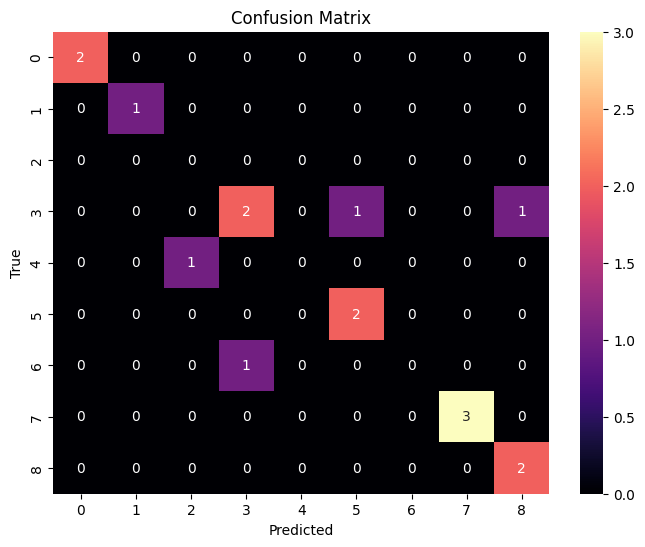

In [ ]:
confuse_matrix = cm(predicted, labels)
plt.figure(figsize=(8, 6))
sns.heatmap(confuse_matrix, annot=True, fmt='d', cmap = 'magma')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
!pip install streamlit torch torchvision pillow matplotlib seaborn pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 100.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 126.3 MB/s eta 0:00:00


In [ ]:
import joblib
import torch

model_info = {
    'state_dict': model.state_dict(),
    'accuracy': accuracy,
    'classes': ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
}

joblib.dump(model_info, 'model.pkl')

['model.pkl']

In [ ]:
%%writefile app.py
import streamlit as st
import torch
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import joblib
import torchvision.transforms as transforms

# Set page config
st.set_page_config(
    page_title="CIFAR-10 Classifier",
    page_icon="🖼️",
    layout="wide"
)

# Title
st.title("CIFAR-10 Image Classification")
st.write("Upload an image to classify it using our pre-trained CNN model")

# CNN Model class (EXACTLY the same as training)
class Conv_NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 16, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout2d(0.25)
        self.depthwise1 = nn.Conv2d(16, 16, 3, padding=1, groups=16, bias=False)
        self.pointwise1 = nn.Conv2d(16, 32, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 32, 3, padding=1, bias=False)
        self.bn4 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.dropout2 = nn.Dropout2d(0.25)
        self.depthwise2 = nn.Conv2d(32, 32, 3, padding=1, groups=32, bias=False)
        self.pointwise2 = nn.Conv2d(32, 64, 1, bias=False)
        self.bn5 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, 3, padding=1, bias=False)
        self.bn6 = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.dropout3 = nn.Dropout2d(0.25)
        self.layer1 = nn.Linear(64 * 4 * 4, 128, bias=False)
        self.bn7 = nn.BatchNorm1d(128)
        self.dropout4 = nn.Dropout(0.5)
        self.layer2 = nn.Linear(128, 64, bias=False)
        self.bn8 = nn.BatchNorm1d(64)
        self.dropout5 = nn.Dropout(0.5)
        self.layer3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        output1 = self.conv1(x)
        output2 = self.bn1(output1)
        output3 = self.relu(output2)
        output4 = self.conv2(output3)
        output5 = self.bn2(output4)
        output6 = self.relu(output5)
        output7 = self.pool1(output6)
        output8 = self.dropout1(output7)
        output9 = self.depthwise1(output8)
        output10 = self.pointwise1(output9)
        output11 = self.bn3(output10)
        output12 = self.relu(output11)
        output13 = self.conv3(output12)
        output14 = self.bn4(output13)
        output15 = self.relu(output14)
        output16 = self.pool2(output15)
        output17 = self.dropout2(output16)
        output18 = self.depthwise2(output17)
        output19 = self.pointwise2(output18)
        output20 = self.bn5(output19)
        output21 = self.relu(output20)
        output22 = self.conv4(output21)
        output23 = self.bn6(output22)
        output24 = self.relu(output23)
        output25 = self.pool3(output24)
        output26 = self.dropout3(output25)
        output27 = torch.flatten(output26, 1)
        output28 = self.layer1(output27)
        output29 = self.bn7(output28)
        output30 = self.relu(output29)
        output31 = self.dropout4(output30)
        output32 = self.layer2(output31)
        output33 = self.bn8(output32)
        output34 = self.relu(output33)
        output35 = self.dropout5(output34)
        output36 = self.layer3(output35)
        return output36

# Load the trained model with debugging
@st.cache_resource
def load_trained_model():
    try:
        # Load the complete model info
        model_info = joblib.load('model.pkl')

        # Create model instance
        model = Conv_NeuralNetwork()

        # Load the state dict
        model.load_state_dict(model_info['state_dict'])
        model.eval()

        # Debug info
        st.sidebar.success(f"✅ Model loaded successfully!")
        st.sidebar.info(f"📊 Training accuracy: {model_info['accuracy']:.2f}%")

        return model

    except FileNotFoundError:
        st.sidebar.error("❌ Model file 'cifar10_model_complete.pkl' not found!")
        st.sidebar.info("💡 Please train and save the model first using:")
        st.sidebar.code("""
        model_info = {
            'state_dict': model.state_dict(),
            'accuracy': your_accuracy,
            'classes': your_classes
        }
        joblib.dump(model_info, 'cifar10_model_complete.pkl')
        """)
        return None
    except Exception as e:
        st.sidebar.error(f"❌ Error loading model: {str(e)}")
        return None

# Load model
model = load_trained_model()

# CIFAR-10 classes
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# Image transformation
def transform_image(image):
    transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    return transform(image).unsqueeze(0)

# Prediction function with debugging
def predict(image_tensor):
    if model is None:
        return None, None

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0] * 100
        predicted_class = torch.argmax(probabilities).item()

        # Debug: show raw outputs
        st.sidebar.write("🔍 Raw outputs:", outputs.numpy().round(2))
        st.sidebar.write("📈 Probabilities:", probabilities.numpy().round(2))

    return predicted_class, probabilities.numpy()

# Main app
if model is None:
    st.error("Model not loaded. Please check the error messages in the sidebar.")
    st.stop()

st.sidebar.title("Navigation")
option = st.sidebar.radio("Choose an option:",
                         ["Classify Image", "Model Info"])

if option == "Classify Image":
    st.header("Classify an Image")

    uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

    if uploaded_file is not None:
        image = Image.open(uploaded_file).convert('RGB')
        st.image(image, caption="Uploaded Image", use_column_width=True)

        if st.button("Classify Image"):
            with st.spinner("Analyzing image..."):
                image_tensor = transform_image(image)
                predicted_class, probabilities = predict(image_tensor)

            if predicted_class is not None:
                # Display results
                col1, col2 = st.columns(2)

                with col1:
                    st.success(f"**Prediction:** {classes[predicted_class]}")
                    st.info(f"**Confidence:** {probabilities[predicted_class]:.2f}%")

                with col2:
                    # Probability chart
                    fig, ax = plt.subplots(figsize=(10, 6))
                    y_pos = np.arange(len(classes))
                    ax.barh(y_pos, probabilities)
                    ax.set_yticks(y_pos)
                    ax.set_yticklabels(classes)
                    ax.invert_yaxis()
                    ax.set_xlabel('Probability (%)')
                    ax.set_title('Class Probabilities')
                    ax.grid(axis='x', alpha=0.3)
                    st.pyplot(fig)
            else:
                st.error("Prediction failed!")

elif option == "Model Info":
    st.header("Model Information")

    st.subheader("Model Architecture")
    st.text(str(model))

    st.subheader("Model Parameters")
    total_params = sum(p.numel() for p in model.parameters())
    st.write(f"Total parameters: {total_params:,}")

    st.subheader("CIFAR-10 Classes")
    for i, class_name in enumerate(classes):
        st.write(f"{i}: {class_name}")

# Test with sample images
st.sidebar.markdown("---")
if st.sidebar.button("Test with random tensor"):
    # Create a random test image
    test_tensor = torch.randn(1, 3, 32, 32)
    predicted_class, probabilities = predict(test_tensor)

    if predicted_class is not None:
        st.sidebar.write(f"🧪 Random test prediction: {classes[predicted_class]}")
        st.sidebar.write(f"📊 Max probability: {probabilities[predicted_class]:.2f}%")

Writing app.py


In [ ]:
!streamlit run app.py &>/dev/null&

In [ ]:
!pkill -f ngrok && streamlit run app.py --server.port 8501 & sleep 5 && ngrok http 8501

^C


In [ ]:
from pyngrok import ngrok

# Set your ngrok authtoken (you need to sign up at ngrok.com for a free account)
!ngrok authtoken 30dLxqJ7zHQFeiIpbFMsX6Ot6wm_6UQQTqwrCv3kjoe3yeYUZ  # Replace with your actual token
public_url = ngrok.connect(addr='8501')
print("Streamlit app is running at:", public_url)

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
Streamlit app is running at: NgrokTunnel: "https://fdec0e496128.ngrok-free.app" -> "http://localhost:8501"
